# Topics
- make_pipeline
- StratifiedKFold
- cross_val_score
- learning_curve
- LearningCurveDisplay
- validation_curve
- GridSearchCV

- confusion_matrix, ConfusionMatrixDisplay
- precision_score, recall_score, f1_score, make_scorer
- roc_curve, roc_auc_score, auc

---

### Step 1: Import Packages

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

import tensorflow as tf

import matplotlib.pyplot as plt
%matplotlib inline

### Step 2: Load the data

In [2]:
df = pd.read_csv(
     'https://archive.ics.uci.edu/ml/'
     'machine-learning-databases'
     '/breast-cancer-wisconsin/wdbc.data',
     header=None)

In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Step 3: Preprocessing

##### Split data to features and output and LabelEncoder output

In [4]:
# split data to feature and outcome
X = df.loc[:,2:].values
y = df.loc[:,1].values

# LabelEncoder output - change from string to numberical
le = LabelEncoder()
y = le.fit_transform(y)

print(f'label classes: {le.classes_}')
print(f'test the mapping: (M,B) {le.transform(['M','B'])}')

label classes: ['B' 'M']
test the mapping: (M,B) [1 0]


### Step 4: Split data to training and testing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    stratify=y, # keep the samle balance before split
    random_state=1
)

### Step 5: Combining transformers and estimators in a pipeline

In [6]:
# create pipeline
pipe_lr = make_pipeline(StandardScaler(), # standardlize the data
                        PCA(n_components=2), # PCA reduces the dimentions to 2
                        LogisticRegression(random_state=1, solver='lbfgs')) # apply the LogisticRegression

In [7]:
# fit training data
pipe_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'au

In [8]:
# predict and test accuracy
y_pred = pipe_lr.predict(X_test)
print('Test Accuracy: %.3f' % pipe_lr.score(X_test, y_test)) # use X_test, y_test

Test Accuracy: 0.956


### Step 6: Using k-fold cross-validation to assess model performance

##### 1) StratifiedKFold: test accuracy on test data

In [9]:
# StratifedKFold will keep the propotion of Classes in train and test
from sklearn.model_selection import StratifiedKFold, cross_val_score

# applit StratifiedKFold, split data to 10 pieces, 9 used for train, 1 used for test
# StratifiedKFold is iterable dataset, with the index for train and test
kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)
scores = []

# iterate over the StratifiedKFold
for idx, (train_idx, test_idx) in enumerate(kfold):
    pipe_lr.fit(X_train[train_idx], y_train[train_idx]) # use training index for training
    score = pipe_lr.score(X_train[test_idx], y_train[test_idx]) # use testing index for test score
    scores.append(score)
    # np.bincount() only apply to positive data, and return a list of counts
    print(f'Fold: {idx+1}, {np.bincount(y_train[train_idx])}, accuracy: {score:.4f}')

Fold: 1, [256 153], accurace: 0.9348
Fold: 2, [256 153], accurace: 0.9348
Fold: 3, [256 153], accurace: 0.9565
Fold: 4, [256 153], accurace: 0.9565
Fold: 5, [256 153], accurace: 0.9348
Fold: 6, [257 153], accurace: 0.9556
Fold: 7, [257 153], accurace: 0.9778
Fold: 8, [257 153], accurace: 0.9333
Fold: 9, [257 153], accurace: 0.9556
Fold: 10, [257 153], accurace: 0.9556


##### 2) cross_val_score: accuracy on the test data

In [10]:
# import the cross_val_score package
from sklearn.model_selection import cross_val_score

# apply the cross_val_score to the training dataset
scores = cross_val_score(
    estimator=pipe_lr, # model
    X = X_train,
    y = y_train,
    cv = 10, # split data to 10 folds
    n_jobs=1 # only use 1 CPU
)

# print all scores
print('CV accuracy scores: %s' % scores) 

# print the range
print('CV accuracy: %.3f +/- %.3f' %(np.mean(scores), np.std(scores)))

CV accuracy scores: [0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]
CV accuracy: 0.950 +/- 0.014


``cross_val_score`` 
- returns a 1D NumPy array of scores, one per fold.
- by default that's the estimators method - R^2 for regressors, accuracy for classifiers.
- scoring='neg_mean_squared_error'; 'r2','roc_auc': 'neg_' prefix on error comback as negated, because Sklearn follows the convention that higher is better.
- cross_val_score(model, X, y, scoring='')
- the typical pattern is to report scores.mean() and scores.std() to capture both central performance and vairnace across folds.

### Step 7: Diagnosing bias and variance problems with learning curves

### Learning Curve

``learning_curve answers one specific question``: how does model performance change as you give it more training data? It's the standard tool for diagnosing whether a model is suffering from high bias (underfitting) or high variance (overfitting).
Here's the mechanism. You give it a list of training-set sizes via train_sizes. For each size, it does the following:

- Carves out a fraction of the data of that size for training.
- Fits the estimator on that subset.
- Scores it twice — once on the training subset itself (training score) and once on a held-out validation fold (validation/test score).
- Repeats this across cv folds and collects all the scores.

In [11]:
from sklearn.model_selection import learning_curve, LearningCurveDisplay

##### First way - learning curve

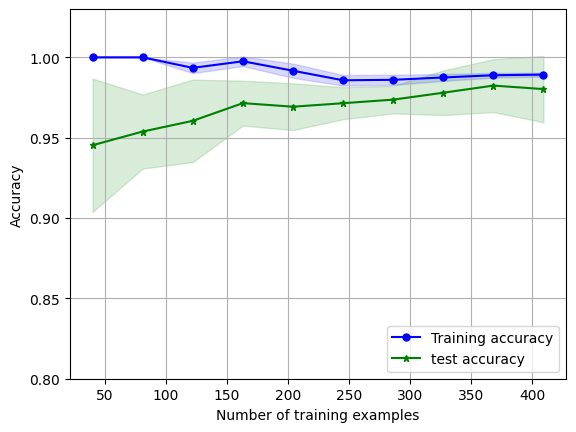

In [ ]:
from sklearn.model_selection import learning_curve
pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(
                                           random_state=1,
                                           solver='lbfgs',
                                           max_iter=10000))

# cv=10, train 10 times per split, so train_score has 10 values per split
train_sizes, train_score, test_score = learning_curve(
    estimator = pipe_lr,
    X = X_train, 
    y = y_train,
    cv = 10,
    train_sizes=np.linspace(0.1, 1, 10), # train size increase from low to high
    n_jobs=1
)

train_mean = train_score.mean(axis=1)
train_std = train_score.std(axis=1)
test_mean = test_score.mean(axis=1)
test_std = test_score.std(axis=1)

plt.plot(train_sizes, train_mean, color='blue', marker='o',
         markersize=5, label='Training accuracy')
plt.fill_between(train_sizes,
                 train_mean + train_std,   # y1 — upper edge
                 train_mean - train_std,   # y2 — lower edge
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', marker='*',
         markersize=5, label='test accuracy')
plt.fill_between(train_sizes,
                 test_mean + test_std,   # y1 — upper edge
                 test_mean - test_std,   # y2 — lower edge
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.show()

##### Second way - learning curve

(0.8, 1.03)

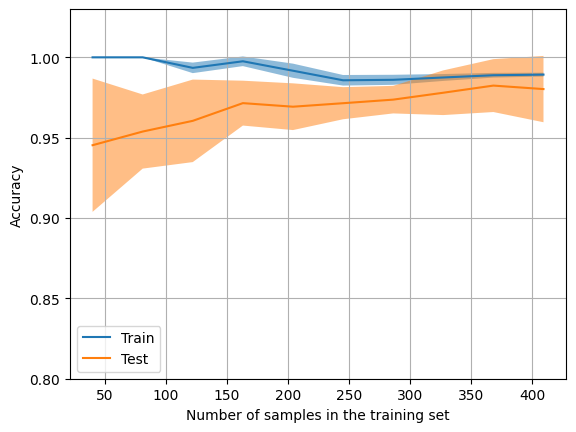

In [13]:
LearningCurveDisplay.from_estimator(
    pipe_lr,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1,1.0, 10),
    cv=10,
    n_jobs=-1,
    scoring='accuracy' # y_axis name
)
plt.grid()
plt.ylim([0.8, 1.03])

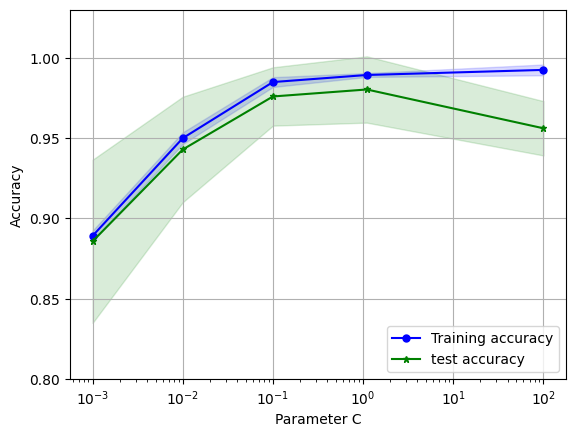

In [ ]:
from sklearn.model_selection import validation_curve
pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(
                                           random_state=1,
                                           solver='lbfgs',
                                           max_iter=10000))

param_range=[0.001,0.01,0.1,1.10, 100.0]
# cv=10, train 10 times per split, so train_score has 10 values per split
train_score, test_score = validation_curve(
    estimator = pipe_lr,
    X = X_train, 
    y = y_train,
    cv = 10,
    param_name = 'logisticregression__C', # <step_name>__<parameter_name>
    param_range=param_range
)

train_mean = train_score.mean(axis=1)
train_std = train_score.std(axis=1)
test_mean = test_score.mean(axis=1)
test_std = test_score.std(axis=1)

plt.plot(param_range, train_mean, color='blue', marker='o',
         markersize=5, label='Training accuracy')
plt.fill_between(param_range,
                 train_mean + train_std,   # y1 — upper edge
                 train_mean - train_std,   # y2 — lower edge
                 alpha=0.15, color='blue')

plt.plot(param_range, test_mean, color='green', marker='*',
         markersize=5, label='test accuracy')
plt.fill_between(param_range,
                 test_mean + test_std,   # y1 — upper edge
                 test_mean - test_std,   # y2 — lower edge
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Parameter C')
# on a linear scale, the distance between 1 to 10 is the same as between 10 and 19. 
# On a log scale, the distance between 1 and 10 is the same as between 10 and 100, and 100 and 1000. 
plt.xscale('log') 
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.show()

``cross_val_score`` — Estimates a model's generalization performance by training and scoring across multiple folds, returning per-fold scores so you see both average performance and its variance.

``StratifiedKFold`` — A cross-validation splitter that partitions data while preserving the class distribution in each fold; essential for imbalanced problems like fraud detection where random splits could leave folds with too few positives.

``learning_curve ``— Diagnoses bias vs. variance by plotting training and validation scores against increasing training set sizes, telling you whether more data would help (overfitting) or whether the model is too simple (underfitting).

``Validation curve``: diagnoses bias vs.Validation curve: diagnoses bias vs. variance by plotting training and cross-validation scores across a range of a single hyperparameter (here, C), revealing where the model underfits (both scores low), overfits (training high, validation low), or hits the sweet spot — so you can pick a good value for that hyperparameter.

### Step 8: Tuning hyperparameters vias grid search

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# chain two steps
pipe_svc = make_pipeline(StandardScaler(),
                        SVC(random_state=1))
# parameter range
param_range=[0.0001, 0.001, 0.01, 0.1,
             1.0, 10.0, 100.0, 1000.0]

# list of two dicts
# first and second dict are run separately, firts dict has 8 * 1 loops
# secodn dirct have 8 * 8 * 1 loops
# combine 8 + 64 = 72
param_grid = [{
    'svc__C': param_range, # <step_name>__<param>, double underscore
    'svc__kernel':['linear']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['rbf']}]

gs = GridSearchCV(estimator=pipe_svc,
                  param_grid = param_grid,
                  scoring='accuracy', # metric used to rank combinations
                  cv=10, #10-fold cross-validation, so each of the 72 combinations is fit 10 times (710 fits total)
                  refit=True, # after finding the best params, refit one final model on the entire
                  # training set. This is what mkes gs itself usable as a fitted estimator afterward
                  n_jobs=-1) # parallelize across all CPU cores
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9846859903381642
{'svc__C': 100.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}


In [16]:
# estimate the performance of the best-selected model
clf = gs.best_estimator_
clf.fit(X_train, y_train)
print('Test accuray: %.3f' % clf.score(X_test, y_test))

Test accuray: 0.974


### Step 9: Algorithm selection with nested cross-validation

In [17]:
gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=2)
scores = cross_val_score(gs, X_train, y_train,
                         scoring='accuracy',
                         cv=5)
print('CV accuracy: %.3f +/- %.3f' % (np.mean(scores),
                             np.std(scores)))

CV accuracy: 0.974 +/- 0.015


In [18]:
from sklearn.tree import DecisionTreeClassifier
gs = GridSearchCV(
    estimator = DecisionTreeClassifier(random_state=0),
    param_grid={
        'max_depth':[1,2,3,4,5,6,7, None]},
    scoring='accuracy',
    cv=2)
scores = cross_val_score(gs, X_train, y_train, 
                         scoring='accuracy', cv=5)
print('CV accuracy: %.3f +/- %.3f' % (np.mean(scores),
np.std(scores)))

CV accuracy: 0.934 +/- 0.016


### Step 10: Looking at different performance evaluation metrics

#### 1) Confusion Matrix

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


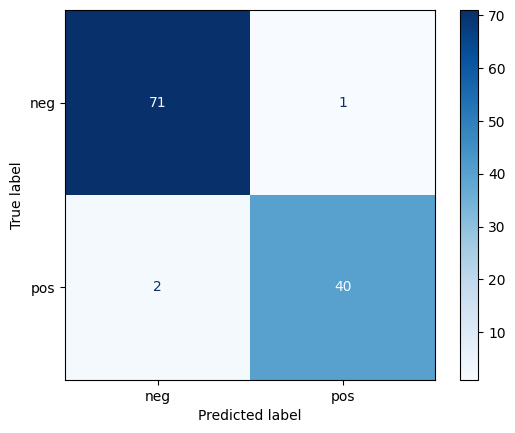

In [20]:
ConfusionMatrixDisplay.from_estimator(pipe_svc, 
                                      X_test, 
                                      y_test, 
                                      display_labels=['neg','pos'], 
                                      cmap='Blues')
plt.show()

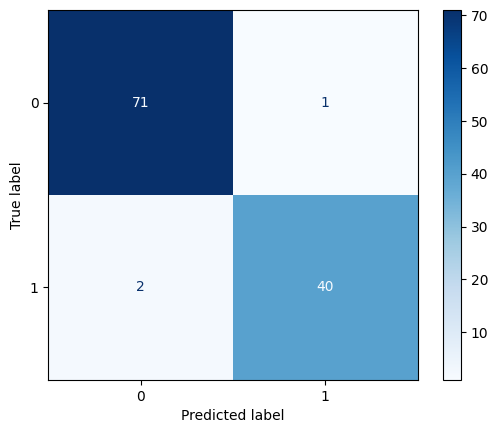

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, 
                                        y_pred,
                                        cmap='Blues')
plt.show()

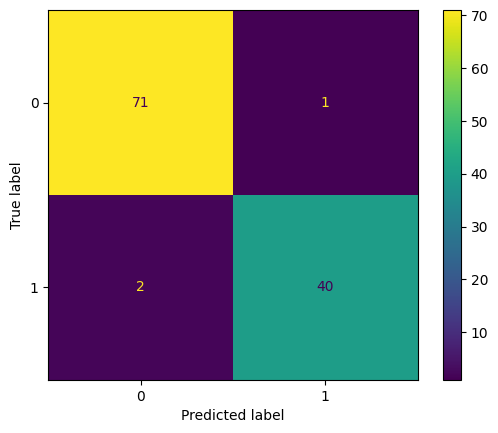

In [22]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm) # can't change color
disp.plot()
plt.show()

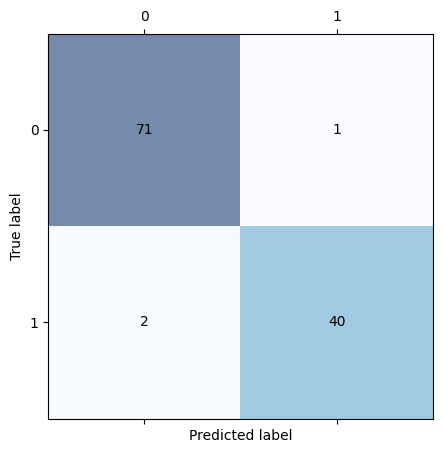

In [23]:
fig, ax = plt.subplots(figsize=(5,5))
ax.matshow(cm, cmap='Blues', alpha=0.56)
for i in range(cm.shape[1]):
    for j in range(cm.shape[0]):
        ax.text(x=j, y=i,
                s=cm[i,j],
                va='center', ha='center')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

#### 2) Optimizing the precision and recall of a classificaiton model

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(f'precision score: {precision_score(y_test, y_pred):.3f}')
print(f'recall score: {recall_score(y_test, y_pred):.3f}')
print(f'F1 score: {f1_score(y_test, y_pred):.3f}')

precision score: 0.976
recall score: 0.952
F1 score: 0.964


In [25]:
# changet he evaluation metrics and specify a different positive label
from sklearn.metrics import make_scorer, f1_score
c_gamma_range = [0.01, 0.1, 1.0, 10.0]
param_grid = [{'svc__C': c_gamma_range,
                # the kernel is the function the SVM uses to measure similarity between two data pints.
                # It's what determines the shape of the decision boundary the classifier can draw.
               'svc__kernel':['linear']}, 
               {'svc__C': c_gamma_range,
                'svc__gamma': c_gamma_range,
                'svc__kernel':['rbf']}] # radial basis function, decays with distance, it allows SVM draw curved, nonlinear boundaries
scorer = make_scorer(f1_score, pos_label=0)
gs = GridSearchCV(estimator=pipe_svc,
                  param_grid = param_grid,
                  scoring=scorer,
                  cv=10)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9861994953378878
{'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


#### 3) Plotting a receiver operating characteristic
- ROC graphs are useful tools to select models for classification based on their performance with respect to the FRP and TPR, which are computated by shifign the decison threshold of the classifier.
- The diagonal of a ROC graph can be intepreted as random gussing.
- ``precision-recall curves`` - used for imbalance data

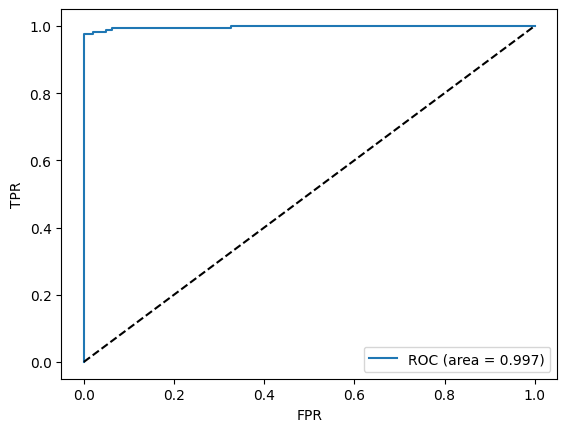

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
pred_prob = pipe_lr.fit(X_train, y_train).predict_proba(X_train)[:,1]
fpr, tpr, threshold = roc_curve(y_train, pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC (area = {roc_auc:.3f})')
plt.plot((0,1), (0,1), 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='best')
plt.show()

#### 4) Scoring metrics fro multiclass classification

#### 5) Dealing with class imbalance

In [46]:
# pull y==0 with 357 samples, but y==1 only 40 samples
X_imb = np.vstack((X[y==0], X[y==1][:40]))
y_imb = np.hstack((y[y==0], y[y==1][:40]))

In [47]:
# if we predict all 0s
y_pred = np.zeros(y_imb.shape[0])
np.mean(y_pred==y_imb)*100

np.float64(89.92443324937027)

In [51]:
from sklearn.utils import resample
print('Number of class 1 examples before: ', X_imb[y_imb==1].shape[0])
X_upsampled, y_upsampled = resample(
    X_imb[y_imb==1],
    y_imb[y_imb==1],
    replace=True,
    n_samples=X_imb[y_imb==0].shape[0],
    random_state=123
)
print('Number of class 1 examples after:',
      X_upsampled.shape[0])

X_bal = np.vstack((X[y==0], X_upsampled))
y_bal = np.hstack((y[y==0], y_upsampled))

y_pred = np.zeros(y_bal.shape[0])
np.mean(y_pred==y_bal) * 100

Number of class 1 examples before:  40
Number of class 1 examples after: 357


np.float64(50.0)